In [216]:
#outliers and its treatment   # vvi this topic

In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [218]:
salary = [4, 40, 45, 68, 65, 58, 78, 90, 57, 74, 91, 92, 88, 68, 57, 48, 99, 97, 68, 77, 89, 140]

In [219]:
# five point summary
#min, 25, 50, 75, max/100th %

np.quantile(salary,[0, .25, .50, .75, 1])

array([  4.  ,  57.25,  71.  ,  89.75, 140.  ])

In [220]:
df = pd.DataFrame(salary, columns= ['salary'])

In [221]:
df.sample()

,salary
16,99


In [222]:
df.size

22

In [223]:
df.describe()

,salary
count,22.000000
mean,72.409091
std,27.049618
min,4.000000
25%,57.250000
50%,71.000000
75%,89.750000
max,140.000000


Text(0.5, 1.0, 'box plot')

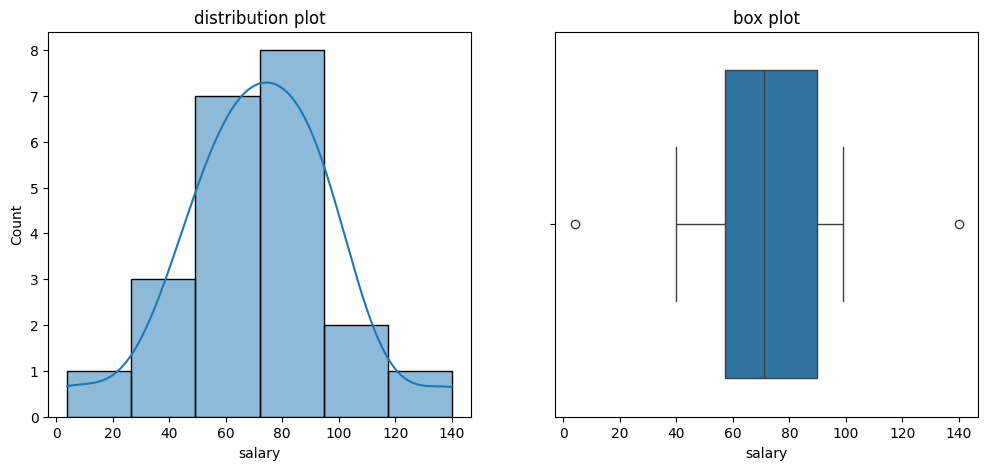

In [224]:
# to check outlier >> distplot, boxplot

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['salary'], kde= True)
plt.title("distribution plot")

plt.subplot(1, 2, 2)
sns.boxplot(data = df, x = 'salary')
plt.title("box plot")


treatment

In [225]:
# Dropping the outlier
# capping the outlier
# Replace with mean median

In [226]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)

iqr = Q3-Q1

lower_fence = Q1 - 1.5 * iqr
upper_fence = Q3 + 1.5 * iqr

In [227]:
lower_fence

8.5

In [228]:
upper_fence

138.5

In [229]:
new_df = df[(df.salary >= lower_fence) & (df.salary <= upper_fence )]

In [230]:
new_df.size

20

Text(0.5, 1.0, 'the box plot')

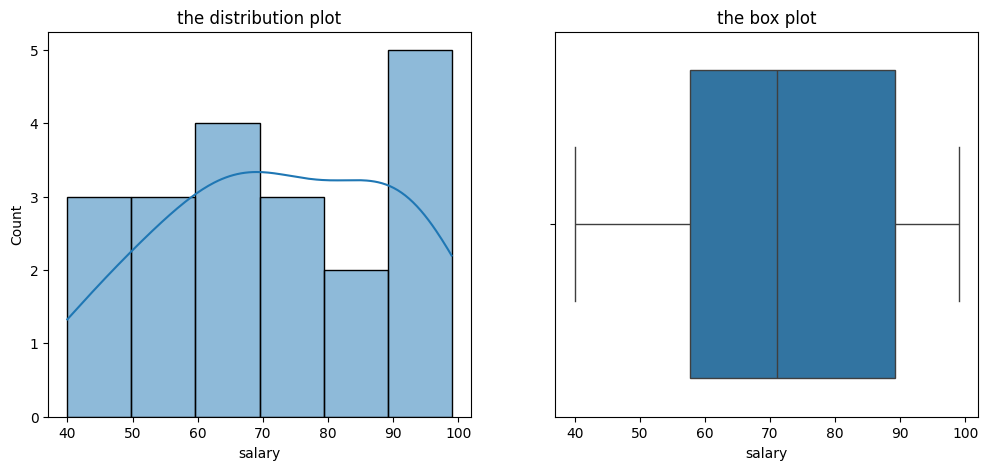

In [231]:
# after treatment the outliar
# to check outlier >> distplot, boxplot

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(new_df['salary'], kde= True)
plt.title("the distribution plot")

plt.subplot(1, 2, 2)
sns.boxplot(data = new_df, x = 'salary')
plt.title("the box plot")

In [232]:
#imputation with mean and median

df['salary_imputed_mean'] = np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].mean(), df['salary'])

In [233]:
df

,salary,salary_imputed_mean
0,4,72.409091
1,40,40.000000
2,45,45.000000
3,68,68.000000
4,65,65.000000
5,58,58.000000
6,78,78.000000
7,90,90.000000
8,57,57.000000
9,74,74.000000


Text(0.5, 1.0, 'the box plot')

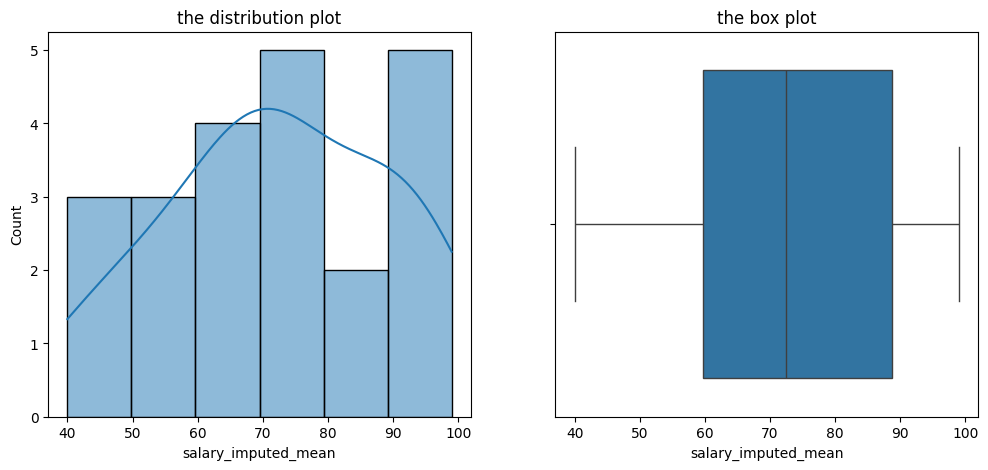

In [236]:
# after treatment the outliar with mean
# to check outlier >> distplot, boxplot

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['salary_imputed_mean'], kde= True)
plt.title("the distribution plot")

plt.subplot(1, 2, 2)
sns.boxplot(data = df, x = 'salary_imputed_mean')
plt.title("the box plot")

In [238]:
df['salary_imputed_median'] = np.where((df.salary >= upper_fence) | (df.salary <= lower_fence), df['salary'].median(), df['salary'])

In [242]:
df.sample()

,salary,salary_imputed_mean,salary_imputed_median
12,88,88.0,88.0


Text(0.5, 1.0, 'the box plot')

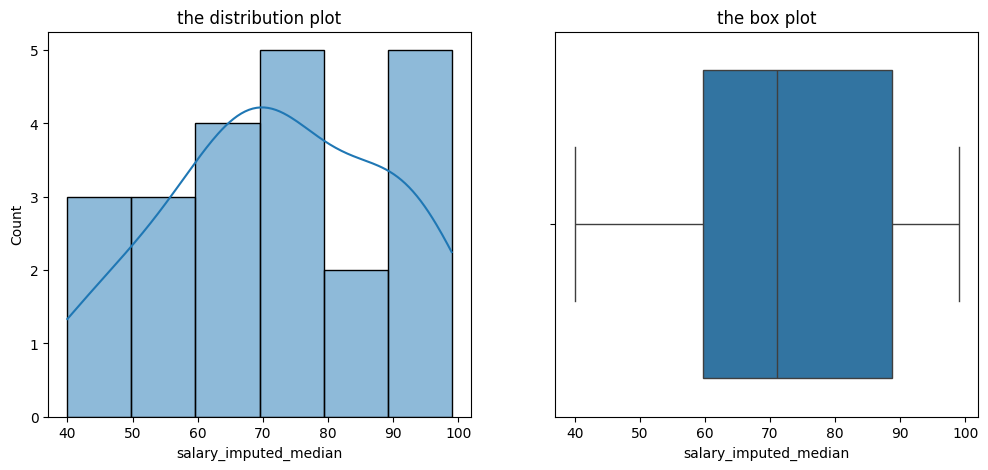

In [240]:
# after treatment the outliar with mean
# to check outlier >> distplot, boxplot

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['salary_imputed_median'], kde= True)
plt.title("the distribution plot")

plt.subplot(1, 2, 2)
sns.boxplot(data = df, x = 'salary_imputed_median')
plt.title("the box plot")

In [249]:
#capping >> replacing with the nearest value which is not outlier

df.head()

,salary,salary_imputed_mean,salary_imputed_median,salary_capped
0,4,72.409091,71.0,40.25
1,40,40.000000,40.0,40.25
2,45,45.000000,45.0,45.00
3,68,68.000000,68.0,68.00
4,65,65.000000,65.0,65.00


In [244]:
lower_cap = df['salary'].quantile(0.05)  # lower cap as 5th persentile 
upper_cap = df['salary'].quantile(0.95)  # upper cap as 95th perswntile 

In [247]:
lower_cap, upper_cap

(40.25, 98.9)

In [245]:
#repliace outliers with the cap 

df['salary_capped'] = np.where(df['salary'] < lower_cap, lower_cap,
                               np.where(df['salary'] > upper_cap, upper_cap,
                                        df['salary']))

In [248]:
df.tail()

,salary,salary_imputed_mean,salary_imputed_median,salary_capped
17,97,97.000000,97.0,97.0
18,68,68.000000,68.0,68.0
19,77,77.000000,77.0,77.0
20,89,89.000000,89.0,89.0
21,140,72.409091,71.0,98.9


Text(0.5, 1.0, 'the box plot')

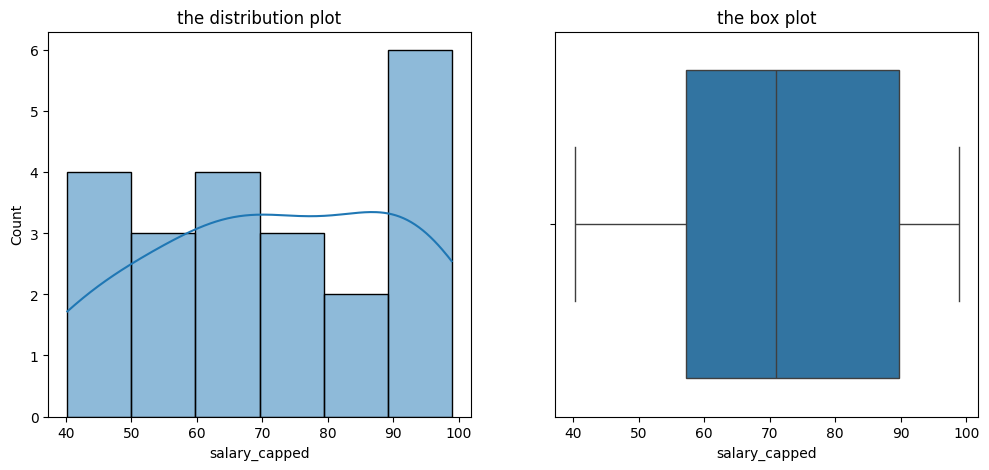

In [250]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['salary_capped'], kde= True)
plt.title("the distribution plot")

plt.subplot(1, 2, 2)
sns.boxplot(data = df, x = 'salary_capped')
plt.title("the box plot")